In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime
import requests

## 1. Data Collection

In [32]:
url = "https://query1.finance.yahoo.com/v8/finance/chart/RELIANCE.NS"

params = {
    "range": "10y",
    "interval": "1d"
}

headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(url, params=params, headers=headers)

data = response.json()

result = data["chart"]["result"][0]

timestamps = result["timestamp"]
quotes = result["indicators"]["quote"][0]

df = pd.DataFrame({
    "Date": pd.to_datetime(timestamps, unit="s"),
    "Open": quotes["open"],
    "High": quotes["high"],
    "Low": quotes["low"],
    "Close": quotes["close"],
    "Volume": quotes["volume"]
})

df.set_index("Date", inplace=True)

df

,Open,High,Low,Close,Volume
Date,,,,,
2016-06-17 03:45:00,223.325760,223.702927,221.748535,222.845734,10534878
2016-06-20 03:45:00,222.217133,226.891663,221.268524,226.343063,10758608
2016-06-21 03:45:00,227.234543,227.245972,223.942947,225.634460,13933068
2016-06-22 03:45:00,225.154434,225.360153,223.348618,224.125809,12788710
2016-06-23 03:45:00,224.000092,224.468674,221.725677,224.114380,9837526
...,...,...,...,...,...
2026-06-11 03:45:00,1258.000000,1276.000000,1253.199951,1263.000000,13117486
2026-06-12 03:45:00,1277.000000,1297.000000,1262.500000,1293.000000,11988785
2026-06-15 03:45:00,1315.300049,1325.000000,1303.300049,1307.000000,18633321


In [33]:
df.head()

,Open,High,Low,Close,Volume
Date,,,,,
2016-06-17 03:45:00,223.325760,223.702927,221.748535,222.845734,10534878
2016-06-20 03:45:00,222.217133,226.891663,221.268524,226.343063,10758608
2016-06-21 03:45:00,227.234543,227.245972,223.942947,225.634460,13933068
2016-06-22 03:45:00,225.154434,225.360153,223.348618,224.125809,12788710
2016-06-23 03:45:00,224.000092,224.468674,221.725677,224.114380,9837526


In [34]:
df.tail()

,Open,High,Low,Close,Volume
Date,,,,,
2026-06-11 03:45:00,1258.000000,1276.000000,1253.199951,1263.000000,13117486
2026-06-12 03:45:00,1277.000000,1297.000000,1262.500000,1293.000000,11988785
2026-06-15 03:45:00,1315.300049,1325.000000,1303.300049,1307.000000,18633321
2026-06-16 03:45:00,1313.400024,1333.400024,1306.400024,1328.800049,18513223
2026-06-17 03:45:00,1333.000000,1334.000000,1317.000000,1330.900024,2520312


## 2. Data Exploration & Visualization

In [35]:
type(df)

pandas.DataFrame

In [36]:
df.shape

(2471, 5)

In [37]:
df.isna().sum()

Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

In [38]:
df.describe()

,Open,High,Low,Close,Volume
count,2471.000000,2471.000000,2471.000000,2471.000000,2.471000e+03
mean,915.564933,924.567086,906.162118,915.018328,1.796599e+07
std,410.511162,413.605743,407.256857,410.306197,1.353783e+07
min,214.982483,219.074112,212.582352,217.485458,0.000000e+00
25%,530.964447,540.233490,521.672516,529.981537,1.019510e+07
50%,1007.500305,1022.037537,995.455139,1006.623474,1.415077e+07
75%,1247.275024,1259.922241,1235.450012,1247.225037,2.080705e+07
max,1604.449951,1611.800049,1585.500000,1600.900024,1.426834e+08


In [39]:
df.dtypes

Open      float64
High      float64
Low       float64
Close     float64
Volume      int64
dtype: object

In [40]:
df.head()

,Open,High,Low,Close,Volume
Date,,,,,
2016-06-17 03:45:00,223.325760,223.702927,221.748535,222.845734,10534878
2016-06-20 03:45:00,222.217133,226.891663,221.268524,226.343063,10758608
2016-06-21 03:45:00,227.234543,227.245972,223.942947,225.634460,13933068
2016-06-22 03:45:00,225.154434,225.360153,223.348618,224.125809,12788710
2016-06-23 03:45:00,224.000092,224.468674,221.725677,224.114380,9837526


In [41]:
df = df.reset_index()

In [42]:
df.head()

,Date,Open,High,Low,Close,Volume
0,2016-06-17 03:45:00,223.325760,223.702927,221.748535,222.845734,10534878
1,2016-06-20 03:45:00,222.217133,226.891663,221.268524,226.343063,10758608
2,2016-06-21 03:45:00,227.234543,227.245972,223.942947,225.634460,13933068
3,2016-06-22 03:45:00,225.154434,225.360153,223.348618,224.125809,12788710
4,2016-06-23 03:45:00,224.000092,224.468674,221.725677,224.114380,9837526


Text(0, 0.5, 'Close price')

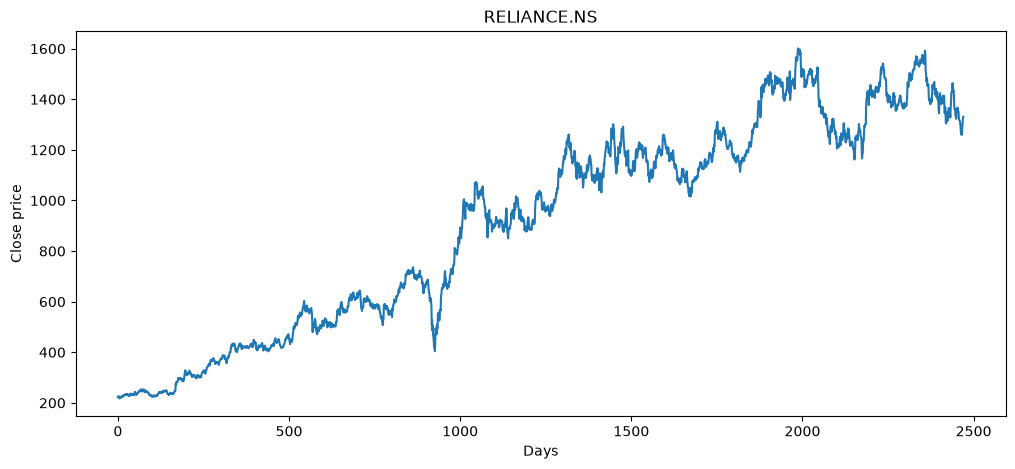

In [43]:
ticker = "RELIANCE.NS"
plt.figure(figsize=(12,5))
plt.plot(df.Close)
plt.title(ticker)
plt.xlabel('Days')
plt.ylabel('Close price')

### 3. Feature Engineering

In [44]:
# 10, 20, 30, 40, 50, 60, 70, 80, 90, 100

# MA of 5 days ==> null null null null 30 40

In [45]:
temp_df = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
print(sum(temp_df[:5])/5)

30.0


In [46]:
df1 = pd.DataFrame([10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
df1

,0
0,10
1,20
2,30
3,40
4,50
5,60
6,70
7,80
8,90
9,100


In [47]:
df1['MA_5'] = df1[0].rolling(5).mean()
df1

,0,MA_5
0,10,NaN
1,20,NaN
2,30,NaN
3,40,NaN
4,50,30.0
5,60,40.0
6,70,50.0
7,80,60.0
8,90,70.0
9,100,80.0


### 100 days Moving Average

In [48]:
df['MA_100'] = df.Close.rolling(100).mean()
df.head()

,Date,Open,High,Low,Close,Volume,MA_100
0,2016-06-17 03:45:00,223.325760,223.702927,221.748535,222.845734,10534878,NaN
1,2016-06-20 03:45:00,222.217133,226.891663,221.268524,226.343063,10758608,NaN
2,2016-06-21 03:45:00,227.234543,227.245972,223.942947,225.634460,13933068,NaN
3,2016-06-22 03:45:00,225.154434,225.360153,223.348618,224.125809,12788710,NaN
4,2016-06-23 03:45:00,224.000092,224.468674,221.725677,224.114380,9837526,NaN


In [49]:
df.head(105)

,Date,Open,High,Low,Close,Volume,MA_100
0,2016-06-17 03:45:00,223.325760,223.702927,221.748535,222.845734,10534878,NaN
1,2016-06-20 03:45:00,222.217133,226.891663,221.268524,226.343063,10758608,NaN
2,2016-06-21 03:45:00,227.234543,227.245972,223.942947,225.634460,13933068,NaN
3,2016-06-22 03:45:00,225.154434,225.360153,223.348618,224.125809,12788710,NaN
4,2016-06-23 03:45:00,224.000092,224.468674,221.725677,224.114380,9837526,NaN
...,...,...,...,...,...,...,...
100,2016-11-16 03:45:00,227.440262,227.851715,224.171524,225.508728,16550762,235.646284
101,2016-11-17 03:45:00,225.383011,228.160294,222.731445,223.497208,12628378,235.617826
102,2016-11-18 03:45:00,225.154434,226.914520,224.468674,225.725891,18163751,235.618740
103,2016-11-21 03:45:00,225.737320,227.108810,224.742981,226.640228,13232434,235.643884


Text(0, 0.5, 'Price')

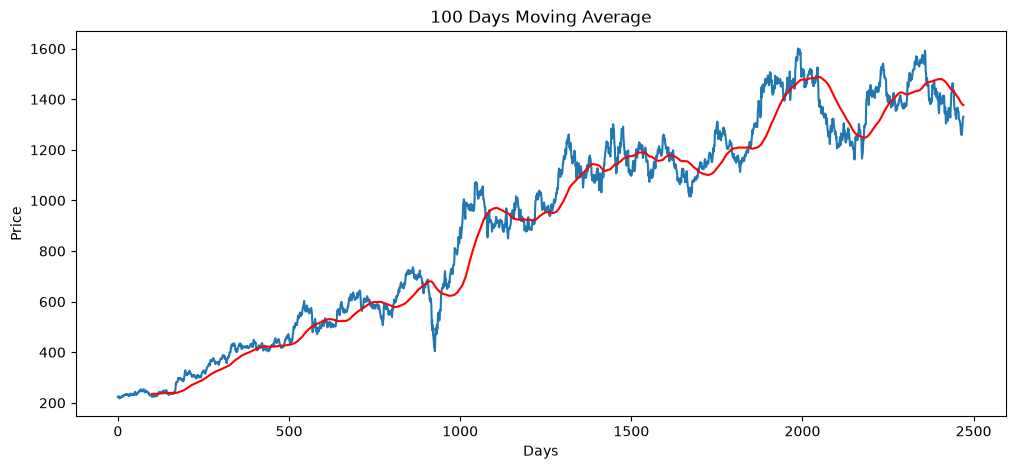

In [50]:
plt.figure(figsize=(12,5))
plt.plot(df.Close)
plt.plot(df['MA_100'], 'r')
plt.title('100 Days Moving Average')
plt.xlabel('Days')
plt.ylabel('Price')

### 200 days Moving Average

In [51]:
df['MA_200'] = df.Close.rolling(200).mean()
df.head(203)

,Date,Open,High,Low,Close,Volume,MA_100,MA_200
0,2016-06-17 03:45:00,223.325760,223.702927,221.748535,222.845734,10534878,NaN,NaN
1,2016-06-20 03:45:00,222.217133,226.891663,221.268524,226.343063,10758608,NaN,NaN
2,2016-06-21 03:45:00,227.234543,227.245972,223.942947,225.634460,13933068,NaN,NaN
3,2016-06-22 03:45:00,225.154434,225.360153,223.348618,224.125809,12788710,NaN,NaN
4,2016-06-23 03:45:00,224.000092,224.468674,221.725677,224.114380,9837526,NaN,NaN
...,...,...,...,...,...,...,...,...
198,2017-04-07 03:45:00,324.885284,327.788269,320.599335,321.525085,31875272,254.436393,NaN
199,2017-04-10 03:45:00,322.302277,325.708160,314.827606,315.753387,30768410,255.341468,245.480561
200,2017-04-11 03:45:00,317.239166,320.119324,313.181824,313.696136,32249647,256.223342,245.934813
201,2017-04-12 03:45:00,316.084808,316.919159,308.850159,309.501617,27448279,257.083386,246.350606


Text(0, 0.5, 'Price')

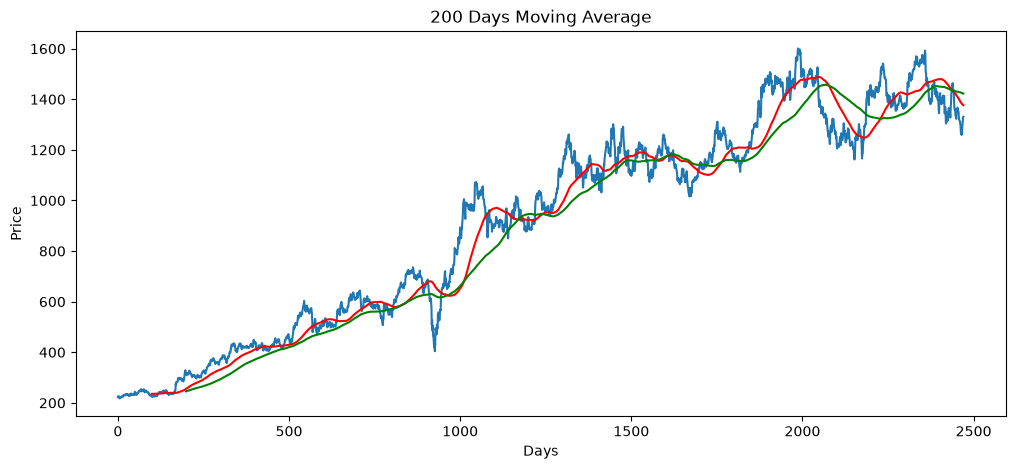

In [52]:
plt.figure(figsize=(12,5))
plt.plot(df.Close)
plt.plot(df['MA_100'], 'r')
plt.plot(df['MA_200'], 'g')
plt.title('200 Days Moving Average')
plt.xlabel('Days')
plt.ylabel('Price')

### Calculating % changed in each trading session

In [53]:
df['Percentage Changed'] = df.Close.pct_change()
df[['Close', 'Percentage Changed']]

,Close,Percentage Changed
0,222.845734,NaN
1,226.343063,0.015694
2,225.634460,-0.003131
3,224.125809,-0.006686
4,224.114380,-0.000051
...,...,...
2466,1263.000000,0.003336
2467,1293.000000,0.023753
2468,1307.000000,0.010828
2469,1328.800049,0.016679


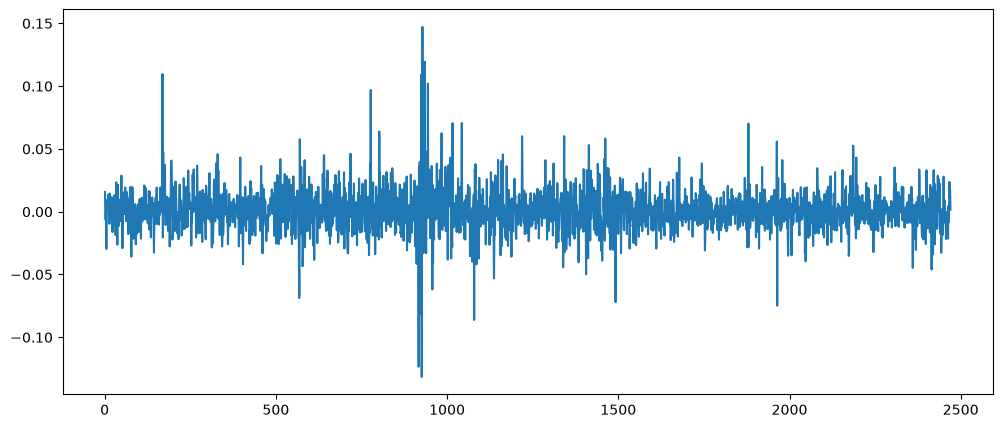

In [54]:
plt.figure(figsize=(12,5))
plt.plot(df['Percentage Changed'])

## 4. Data Preprocessing

In [55]:
df.shape

(2471, 9)

In [56]:
# Splitting data into Training and Testing Datasets
data_training = pd.DataFrame(df.Close[0:int(len(df)*0.7)])
data_testing = pd.DataFrame(df.Close[int(len(df)*0.7): int(len(df))])

print(data_training)
print(data_testing)

            Close
0      222.845734
1      226.343063
2      225.634460
3      224.125809
4      224.114380
...           ...
1724  1145.419556
1725  1146.434814
1726  1163.371826
1727  1177.678345
1728  1178.001465

[1729 rows x 1 columns]
            Close
1729  1189.469727
1730  1177.655273
1731  1180.101196
1732  1183.424072
1733  1170.132812
...           ...
2466  1263.000000
2467  1293.000000
2468  1307.000000
2469  1328.800049
2470  1330.900024

[742 rows x 1 columns]


In [57]:
data_training

,Close
0,222.845734
1,226.343063
2,225.634460
3,224.125809
4,224.114380
...,...
1724,1145.419556
1725,1146.434814
1726,1163.371826
1727,1177.678345


In [58]:
data_testing

,Close
1729,1189.469727
1730,1177.655273
1731,1180.101196
1732,1183.424072
1733,1170.132812
...,...
2466,1263.000000
2467,1293.000000
2468,1307.000000
2469,1328.800049


In [59]:
# Scaling down the data betwen 0 and 1

In [66]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

In [67]:
data_training_array = scaler.fit_transform(data_training)
data_training_array

array([[0.00494547],
       [0.00817217],
       [0.0075184 ],
       ...,
       [0.87268962],
       [0.88588904],
       [0.88618715]], shape=(1729, 1))

In [68]:
type(data_training_array)

numpy.ndarray

In [69]:
data_training_array.shape

(1729, 1)

## 5. Sequence Creation

In [70]:
x_train = []
y_train = []

for i in range(100, data_training_array.shape[0]):
    x_train.append(data_training_array[i-100: i])
    y_train.append(data_training_array[i,0])

x_train, y_train = np.array(x_train), np.array(y_train)

In [71]:
x_train

array([[[0.00494547],
        [0.00817217],
        [0.0075184 ],
        ...,
        [0.01243224],
        [0.010608  ],
        [0.00715987]],

       [[0.00817217],
        [0.0075184 ],
        [0.00612649],
        ...,
        [0.010608  ],
        [0.00715987],
        [0.00740239]],

       [[0.0075184 ],
        [0.00612649],
        [0.00611595],
        ...,
        [0.00715987],
        [0.00740239],
        [0.00554653]],

       ...,

       [[0.8500165 ],
        [0.84001053],
        [0.85478533],
        ...,
        [0.86366292],
        [0.85612657],
        [0.85706327]],

       [[0.84001053],
        [0.85478533],
        [0.85303955],
        ...,
        [0.85612657],
        [0.85706327],
        [0.87268962]],

       [[0.85478533],
        [0.85303955],
        [0.85191128],
        ...,
        [0.85706327],
        [0.87268962],
        [0.88588904]]], shape=(1629, 100, 1))

In [72]:
x_train.ndim

3

In [73]:
y_train.ndim

1

In [74]:
x_train.shape

(1629, 100, 1)

In [75]:
y_train.shape

(1629,)

## 6. Model building

In [76]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [77]:
# ML Model
from keras.models import Sequential
from keras.layers import Dense, LSTM, Input

In [78]:
model = Sequential()
model.add(Input(shape=(100, 1)))
model.add(LSTM(units=128, activation='tanh', return_sequences=True))
model.add(LSTM(units=64))
model.add(Dense(25))
model.add(Dense(1))

### Model Training

In [79]:
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(x_train, y_train, epochs=50)

Epoch 1/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - loss: 0.0211
Epoch 2/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 9.2348e-04
Epoch 3/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 8.4998e-04
Epoch 4/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 8.4659e-04
Epoch 5/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 8.3735e-04
Epoch 6/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 7.7746e-04
Epoch 7/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 7.9672e-04
Epoch 8/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 7.0033e-04
Epoch 9/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 7.1869e-04
Epoch 10/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 6.5272e-04
Epoch 11/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 7.3299e-04
Epoch 12/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 6.5296e-04
Epoch 13/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 5.8341e-04
Epoch 14/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 6.1039e-04
Epoch 15/50
51/51 ━

In [82]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                        │ (None, 100, 128)            │          66,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 25)                  │           1,625 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 352,859 (1.35 MB)

 Trainable params: 117,619 (459.45 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 235,240 (918.91 KB)

In [86]:
# Save the trained model
model.save('stock_prediction_model.keras')

### 8. Preparing Test Data

In [89]:
data_training.tail(100)

,Close
1629,1142.073608
1630,1140.850708
1631,1127.282593
1632,1121.583008
1633,1114.960571
...,...
1724,1145.419556
1725,1146.434814
1726,1163.371826
1727,1177.678345


In [90]:
data_testing

,Close
1729,1189.469727
1730,1177.655273
1731,1180.101196
1732,1183.424072
1733,1170.132812
...,...
2466,1263.000000
2467,1293.000000
2468,1307.000000
2469,1328.800049


In [91]:
past_100_days = data_training.tail(100)
past_100_days

,Close
1629,1142.073608
1630,1140.850708
1631,1127.282593
1632,1121.583008
1633,1114.960571
...,...
1724,1145.419556
1725,1146.434814
1726,1163.371826
1727,1177.678345


In [93]:
final_df = pd.concat([past_100_days, data_testing], ignore_index=True)
final_df

,Close
0,1142.073608
1,1140.850708
2,1127.282593
3,1121.583008
4,1114.960571
...,...
837,1263.000000
838,1293.000000
839,1307.000000
840,1328.800049


In [95]:
input_data = scaler.fit_transform(final_df)
input_data

array([[0.21571284],
       [0.2136225 ],
       [0.19043007],
       [0.18068758],
       [0.16936763],
       [0.14301966],
       [0.10736341],
       [0.12503389],
       [0.12037955],
       [0.10937509],
       [0.09915937],
       [0.10077647],
       [0.08693196],
       [0.08255388],
       [0.11888075],
       [0.12211497],
       [0.1068113 ],
       [0.09631952],
       [0.13950939],
       [0.1819892 ],
       [0.1804904 ],
       [0.18849727],
       [0.16814489],
       [0.18368538],
       [0.14014038],
       [0.13114739],
       [0.14392691],
       [0.13142344],
       [0.09568833],
       [0.11253043],
       [0.0984493 ],
       [0.14526796],
       [0.1636483 ],
       [0.17047206],
       [0.12463932],
       [0.09580664],
       [0.06567234],
       [0.05892765],
       [0.02824103],
       [0.01944523],
       [0.01723657],
       [0.        ],
       [0.05399725],
       [0.05944032],
       [0.03672134],
       [0.00161711],
       [0.0286354 ],
       [0.036

In [96]:
x_test = []
y_test = []

for i in range(100, input_data.shape[0]):
    x_test.append(input_data[i-100: i])
    y_test.append(input_data[i, 0])

In [97]:
x_test, y_test = np.array(x_test), np.array(y_test)

In [100]:
x_test[0].shape

(100, 1)

In [101]:
x_test

array([[[0.21571284],
        [0.2136225 ],
        [0.19043007],
        ...,
        [0.25211859],
        [0.2765732 ],
        [0.27712552]],

       [[0.2136225 ],
        [0.19043007],
        [0.18068758],
        ...,
        [0.2765732 ],
        [0.27712552],
        [0.29672859]],

       [[0.19043007],
        [0.18068758],
        [0.16936763],
        ...,
        [0.27712552],
        [0.29672859],
        [0.27653376]],

       ...,

       [[0.75556537],
        [0.67984184],
        [0.64633895],
        ...,
        [0.41523721],
        [0.42241632],
        [0.47369631]],

       [[0.67984184],
        [0.64633895],
        [0.66445784],
        ...,
        [0.42241632],
        [0.47369631],
        [0.49762698]],

       [[0.64633895],
        [0.66445784],
        [0.66086828],
        ...,
        [0.47369631],
        [0.49762698],
        [0.53489052]]], shape=(742, 100, 1))

## 9. Making Predictions

In [102]:
y_predicted = model.predict(x_test)

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step


In [103]:
y_predicted

array([[0.27243248],
       [0.2873363 ],
       [0.2836892 ],
       [0.27995354],
       [0.28058675],
       [0.26971075],
       [0.25414672],
       [0.23830436],
       [0.2311873 ],
       [0.24277608],
       [0.26138702],
       [0.29973912],
       [0.31155407],
       [0.30942878],
       [0.32769483],
       [0.33677712],
       [0.38371858],
       [0.4249441 ],
       [0.44218302],
       [0.43190038],
       [0.42107725],
       [0.44284075],
       [0.4681697 ],
       [0.4899375 ],
       [0.49629644],
       [0.4526676 ],
       [0.4032322 ],
       [0.382923  ],
       [0.39996347],
       [0.40224504],
       [0.4156716 ],
       [0.43438268],
       [0.42412317],
       [0.4013719 ],
       [0.38414484],
       [0.39425275],
       [0.4100453 ],
       [0.41029084],
       [0.4164726 ],
       [0.4252305 ],
       [0.4343657 ],
       [0.4534065 ],
       [0.46091926],
       [0.44209808],
       [0.44045612],
       [0.42259952],
       [0.41349977],
       [0.412

In [104]:
y_test

array([0.29672859, 0.27653376, 0.28071466, 0.28639456, 0.26367537,
       0.24730671, 0.23216058, 0.23287065, 0.25894236, 0.27531102,
       0.32694177, 0.30568214, 0.30232941, 0.34512492, 0.34106233,
       0.42109176, 0.44448137, 0.44688741, 0.4273632 , 0.42554892,
       0.46972491, 0.48846018, 0.50534172, 0.50262686, 0.43331332,
       0.38942611, 0.38805877, 0.42258721, 0.40250255, 0.42399754,
       0.44228732, 0.41147655, 0.38852888, 0.37959744, 0.4083571 ,
       0.42057887, 0.40758777, 0.42173255, 0.43134754, 0.44049243,
       0.46621798, 0.4644231 , 0.43267232, 0.44874009, 0.41728832,
       0.41677544, 0.41916855, 0.38293077, 0.37314488, 0.35212   ,
       0.33212089, 0.33015511, 0.320711  , 0.32553979, 0.32387323,
       0.33489855, 0.33925723, 0.34207767, 0.35592322, 0.37848655,
       0.34793222, 0.35835911, 0.36028211, 0.36417088, 0.34588089,
       0.29947246, 0.28464412, 0.27622557, 0.26383291, 0.26558501,
       0.28814813, 0.2584059 , 0.26772168, 0.2447738 , 0.24135

In [105]:
y_predicted = scaler.inverse_transform(y_predicted.reshape(-1, 1)).flatten()
y_test = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

In [106]:
y_predicted

array([1175.2559, 1183.975 , 1181.8413, 1179.656 , 1180.0264, 1173.6636,
       1164.5583, 1155.2902, 1151.1266, 1157.9062, 1168.7941, 1191.231 ,
       1198.143 , 1196.8997, 1207.5857, 1212.899 , 1240.361 , 1264.4788,
       1274.5641, 1268.5483, 1262.2167, 1274.9487, 1289.7668, 1302.5015,
       1306.2217, 1280.6976, 1251.7769, 1239.8955, 1249.8645, 1251.1993,
       1259.0542, 1270.0006, 1263.9985, 1250.6885, 1240.6104, 1246.5236,
       1255.7626, 1255.9062, 1259.5227, 1264.6464, 1269.9906, 1281.1299,
       1285.5251, 1274.5143, 1273.5536, 1263.107 , 1257.7836, 1257.4701,
       1245.8176, 1236.5677, 1226.1428, 1215.2131, 1210.0609, 1205.8868,
       1206.0421, 1206.4673, 1210.3353, 1214.0071, 1216.3522, 1221.3853,
       1231.2153, 1225.863 , 1224.1233, 1224.2074, 1225.7738, 1220.6816,
       1202.2842, 1187.5062, 1178.8414, 1172.3859, 1170.7323, 1178.0621,
       1174.6144, 1173.8885, 1166.8873, 1161.1055, 1158.239 , 1158.2795,
       1153.968 , 1153.4988, 1163.1248, 1171.2614, 

In [107]:
y_test

array([1189.46972656, 1177.65527344, 1180.10119629, 1183.42407227,
       1170.1328125 , 1160.5567627 , 1151.69592285, 1152.11132812,
       1167.3638916 , 1176.93994141, 1207.1451416 , 1194.70776367,
       1192.74633789, 1217.78271484, 1215.40600586, 1262.22509766,
       1275.90856934, 1277.31616211, 1265.89404297, 1264.8326416 ,
       1290.67663574, 1301.63720703, 1311.51330566, 1309.92504883,
       1269.375     , 1243.69995117, 1242.90002441, 1263.09997559,
       1251.34997559, 1263.92504883, 1274.625     , 1256.59997559,
       1243.17504883, 1237.94995117, 1254.77502441, 1261.92504883,
       1254.32495117, 1262.59997559, 1268.22497559, 1273.57495117,
       1288.625     , 1287.57495117, 1269.        , 1278.40002441,
       1260.        , 1259.69995117, 1261.09997559, 1239.90002441,
       1234.17504883, 1221.875     , 1210.17504883, 1209.02502441,
       1203.5       , 1206.32495117, 1205.34997559, 1211.80004883,
       1214.34997559, 1216.        , 1224.09997559, 1237.30004

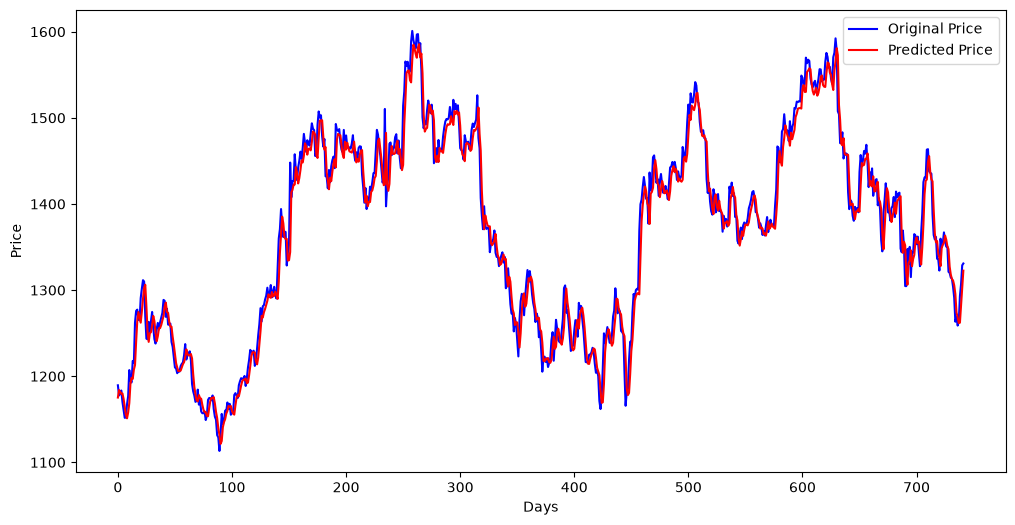

In [114]:
plt.figure(figsize=(12, 6))
plt.plot(y_test, 'b', label='Original Price')
plt.plot(y_predicted, 'r', label='Predicted Price')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend()

(1200.0, 1600.0)

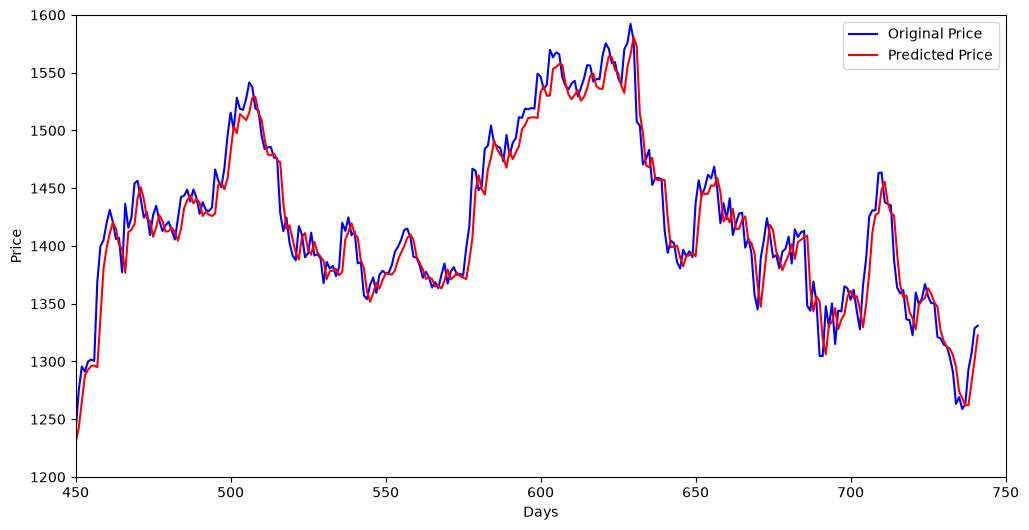

In [113]:
plt.figure(figsize=(12, 6))
plt.plot(y_test, 'b', label='Original Price')
plt.plot(y_predicted, 'r', label='Predicted Price')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend()
plt.xlim(450, 750)
plt.ylim(1200, 1600)

## 10. Model Evalution

In [120]:
# Mean Squared Error (MSE)
55

In [117]:
mse = mean_squared_error(y_test, y_predicted)
print(f"Mean Squared Error (MSE): {mse}")

Mean Squared Error (MSE): 377.17602779127856


In [119]:
# Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)
print(f"Root Mean Squared Error (RMSE): {rmse}")

Root Mean Squared Error (RMSE): 19.42102025618836


In [121]:
# R-Squared - How well your model predictions match the actual value
r2 = r2_score(y_test, y_predicted)
print(f"R-Squared: {r2}")

R-Squared: 0.9717107429465127
